In [1]:
!pip install pyportfolioopt

In [1]:
import pandas as pd #manejar datos en tablas.
import numpy as np #cálculos numéricos
import matplotlib.pyplot as plt #graficar
from pypfopt import expected_returns, risk_models #PyPortfolioOpt para optimizar portafolios usando teoría moderna de portafolios.
from pypfopt.efficient_frontier import EfficientFrontier
from scipy import stats # Para regresión lineal

In [3]:
# 1. Cargar datos de precios
data = pd.read_csv("DJIA_DATA.csv", index_col=0, parse_dates=True)
data = data.dropna()

#Cargamos los datos desde el archivo IPSA DATA.csv, donde las columnas son precios diarios y las filas son fechas.
#Eliminamos filas con valores faltantes para evitar errores en los cálculos.

In [4]:
# 2. Cargamos datos del índice de mercado
market_data = pd.read_csv("DJIA_MARKET.csv", index_col=0, parse_dates=True)
market_data = market_data.dropna()

In [5]:
# 3. Calculamos retornos diarios de los activos y el mercado
mu = expected_returns.mean_historical_return(data, frequency=252)
S = risk_models.sample_cov(data, frequency=252)

display(mu)
display(S)


#252 es el número estándar de días bursátiles en un año (CHILE).

,0
AMZN,0.403152
AXP,0.313277
AMGN,0.076420
AAPL,0.261475
BA,-0.030322
CAT,0.137400
CSCO,0.116814
CVX,-0.055079
GS,0.253525
HD,0.083941


,AMZN,AXP,AMGN,AAPL,BA,CAT,CSCO,CVX,GS,HD,...,PG,SHW,TRV,UNH,CRM,NVDA,VZ,V,WMT,DIS
AMZN,0.105097,0.042223,0.009608,0.041706,0.038173,0.032120,0.027344,0.010575,0.037051,0.025229,...,0.000313,0.029244,0.008568,-0.001467,0.051978,0.084826,-0.000318,0.022222,0.019642,0.032938
AXP,0.042223,0.079776,0.013783,0.031777,0.041830,0.046737,0.026967,0.024137,0.054663,0.025635,...,0.002540,0.029358,0.023800,0.008919,0.037737,0.053108,0.007153,0.029549,0.018529,0.039699
AMGN,0.009608,0.013783,0.058179,0.014595,0.010601,0.016240,0.013191,0.012527,0.016780,0.013889,...,0.011418,0.015095,0.011974,0.011174,0.010535,0.005192,0.012380,0.011363,0.010846,0.010546
AAPL,0.041706,0.031777,0.014595,0.069579,0.034404,0.028119,0.022792,0.016921,0.029250,0.021742,...,0.006397,0.024973,0.011955,0.001539,0.032080,0.057310,0.005931,0.021770,0.016846,0.028557
BA,0.038173,0.041830,0.010601,0.034404,0.118698,0.033005,0.021424,0.022118,0.040380,0.021656,...,0.003639,0.025037,0.019421,0.003885,0.033830,0.043155,0.001855,0.019394,0.019607,0.032458
CAT,0.032120,0.046737,0.016240,0.028119,0.033005,0.084237,0.026199,0.031842,0.050706,0.028402,...,0.001279,0.030238,0.020278,0.005926,0.032300,0.048434,0.008217,0.020902,0.010813,0.032673
CSCO,0.027344,0.026967,0.013191,0.022792,0.021424,0.026199,0.043697,0.017577,0.025934,0.017511,...,0.004539,0.016947,0.009450,0.007155,0.024698,0.036291,0.007995,0.016920,0.016452,0.022105
CVX,0.010575,0.024137,0.012527,0.016921,0.022118,0.031842,0.017577,0.053990,0.028443,0.014242,...,0.003676,0.008418,0.018896,0.007648,0.013054,0.011795,0.010452,0.014605,0.008332,0.023837
GS,0.037051,0.054663,0.016780,0.029250,0.040380,0.050706,0.025934,0.028443,0.079923,0.027548,...,0.001131,0.027680,0.024484,0.006288,0.035256,0.049983,0.007549,0.025358,0.015761,0.035847
HD,0.025229,0.025635,0.013889,0.021742,0.021656,0.028402,0.017511,0.014242,0.027548,0.048064,...,0.007925,0.032829,0.012146,0.005166,0.019966,0.025122,0.009190,0.014873,0.014547,0.021902


In [6]:
# 4. Portafolio de mínima varianza
#Creamos el portafolio optimizado que minimiza el riesgo (volatilidad) sin importar retorno.
#Guardamos el retorno (ret_min), riesgo (vol_min) y ratio de Sharpe (sharpe_min).
ef_min = EfficientFrontier(mu, S)
ef_min.min_volatility()
ret_min, vol_min, sharpe_min = ef_min.portfolio_performance()

# Imprimimos resultado
print("Portafolio de Mínima Varianza")
print(f"Retorno Esperado: {ret_min:.2%}, Volatilidad: {vol_min:.2%}, Sharpe: {sharpe_min:.2f}")

# Constitución del portafolio (peso por acción)
#Limpiamos los pesos irrelevantes (cercanos a 0).
#Mostramos solo los activos que tienen peso en el portafolio óptimo.

df_weights = pd.DataFrame.from_dict(ef_min.clean_weights(), orient='index', columns=['Peso'])
df_weights.index.name = 'Activo'
df_weights = df_weights[df_weights['Peso'] > 0].sort_values('Peso', ascending=False)
display(df_weights)


Portafolio de Mínima Varianza
Retorno Esperado: 11.40%, Volatilidad: 10.37%, Sharpe: 1.10


,Peso
Activo,
KO,0.19829
JNJ,0.16686
MSFT,0.09147
PG,0.08600
UNH,0.06333
CVX,0.06325
VZ,0.05909
MCD,0.05625
MRK,0.05324


In [7]:
# 5. Portafolio de máximo Sharpe
# Buscamos el portafolio con el mejor equilibrio entre retorno y riesgo (máximo ratio de Sharpe).
ef_sharpe = EfficientFrontier(mu, S)
ef_sharpe.max_sharpe()
ret_sharpe, vol_sharpe, sharpe_sharpe = ef_sharpe.portfolio_performance()

#Imprimimos el resultado
print("Portafolio de Máxima Sharpe")
print(f"Retorno Esperado: {ret_sharpe:.2%}, Volatilidad: {vol_sharpe:.2%}, Sharpe: {sharpe_sharpe:.2f}")

#Mostramos los pesos significativos para el portafolio de máxima Sharpe.
#Limpiamos los pesos irrelevantes (cercanos a 0).
df_sharpe = pd.DataFrame.from_dict(ef_sharpe.clean_weights(), orient='index', columns=['Peso'])
df_sharpe.index.name = 'Activo'
df_sharpe = df_sharpe[df_sharpe['Peso'] > 0].sort_values('Peso', ascending=False)
display(df_sharpe)


Portafolio de Máxima Sharpe
Retorno Esperado: 57.04%, Volatilidad: 18.18%, Sharpe: 3.14


,Peso
Activo,
WMT,0.37127
NVDA,0.26549
KO,0.13330
VZ,0.10717
IBM,0.05598
TRV,0.03795
JPM,0.02884


In [8]:
# 6. Construcción de la frontera eficiente
#Establecemos un rango de retornos objetivo entre ret_min y el máximo retorno posible (ret_max) para construir la frontera eficiente.
rf = 0.0682  # Definimos la Tasa libre de riesgo anual
ret_max = mu.max() #mu es el vector de retornos esperados de los activos (calculados previamente). La función max() encuentra el valor máximo en el vector mu, es decir, el retorno máximo esperado entre todos los activos.
target_returns = np.linspace(ret_min, ret_max, 100) #Utiliza np.linspace() para crear un array de 100 valores entre ret_min (retorno mínimo) y ret_max (retorno máximo).

frontier_returns = [] # almacenará los retornos de cada portafolio en la frontera eficiente.
frontier_risks = [] #almacenará el riesgo (volatilidad) de cada portafolio.
frontier_sharpes = [] #almacenará el ratio de Sharpe de cada portafolio.
pesos_portafolios = [] #almacenará los pesos de los activos en cada portafolio.

for i, r in enumerate(target_returns): #Iniciamos un bucle que recorre los 100 valores de target_returns (los retornos objetivo) utilizando enumerate() para obtener tanto el índice i como el valor del retorno r en cada iteración.
    ef = EfficientFrontier(mu, S)
    try:
        ef.efficient_return(target_return=r, market_neutral=False) #Intenta calcular el portafolio más eficiente que tenga un retorno esperado cercano a r (el retorno objetivo de la frontera eficiente).
        ret, risk, _ = ef.portfolio_performance()
        sharpe = (ret - rf) / risk #Calculamos ratio sharpe
        weights = ef.clean_weights() #Obtenemos pesos

        frontier_returns.append(ret)
        frontier_risks.append(risk)
        frontier_sharpes.append(sharpe)
        pesos_portafolios.append(weights)
    except Exception as e: #Si ocurre cualquier error dentro del bloque try, se captura la excepción y se almacena en la variable e, pero el código continuará ejecutándose.
        continue  # Si ocurre un error, el comando continue hace que el bucle pase a la siguiente iteración, es decir, se salta el cálculo de ese portafolio en particular y continúa con el siguiente.


#Para cada rendimiento objetivo:
##Calcula el portafolio más eficiente (mínimo riesgo).
##Obtiene su riesgo, rendimiento y ratio de Sharpe.
##Guarda también los pesos de cada portafolio.
##Si no se puede resolver, lo omite y se sigue ejecutando.


In [9]:
# 7. Calculamos betas de cada activo respecto al mercado

# Calcular retornos diarios
returns_assets = data.pct_change().dropna()
returns_market = market_data['DJIA'].pct_change().dropna()

# Alinear fechas entre activos e índice de mercado
combined = returns_assets.join(returns_market, how='inner') #Une los retornos de los activos (returns_assets) con los retornos del índice (returns_market) en un solo DataFrame.
returns_assets = combined.drop(columns=['DJIA']) #significa que solo se conservarán las fechas comunes a ambos (activos e índice).
returns_market = combined['DJIA']

betas = {} #Inicializamos un diccionario vacío llamado betas, que se utilizará para almacenar las betas de cada activo en el portafolio.

for asset in returns_assets.columns: # Iniciamos un bucle que recorre todas las columnas de asset_returns.
    # Realizamos regresión lineal de los rendimientos del activo vs el mercado
    slope, _, _, _, _ = stats.linregress(returns_market, returns_assets[asset]) #Esta línea realiza una regresión lineal entre los rendimientos del mercado y los rendimientos del activo. La función linregress de la librería scipy.stats devuelve varios valores, pero solo estamos interesados en la pendiente de la regresión (es decir, la beta del activo), que es el primer valor de la salida.
    betas[asset] = slope #Guardamos la beta de cada activo en el diccionario betas, donde asset es la clave (nombre del activo) y slope es el valor (la beta calculada).

#Slope = pendiente = beta
#Los otros valores (_) son el intercepto, el valor de r (coeficiente de correlación), el valor de p (valor p) y el error estándar de la pendiente. Estos no nos interesan, por lo que los vamos a omitir con el guion bajo (_).


# Mostramos las betas de los activos
print("Betas de los activos con respecto al mercado:")
for asset, beta in betas.items(): #Iterar sobre todas las betas almacenadas en el diccionario para imprimirlas.
    print(f"{asset}: {beta:.4f}")

Betas de los activos con respecto al mercado:
AMZN: 1.3155
AXP: 1.5846
AMGN: 0.6637
AAPL: 1.2981
BA: 1.4137
CAT: 1.4340
CSCO: 0.9809
CVX: 0.9572
GS: 1.6271
HD: 0.8786
HON: 0.9953
IBM: 0.8787
JNJ: 0.3301
KO: 0.3371
JPM: 1.3292
MCD: 0.5533
MMM: 1.2661
MRK: 0.4689
MSFT: 0.9830
NKE: 1.0345
PG: 0.3263
SHW: 1.0436
TRV: 0.9091
UNH: 0.6768
CRM: 1.3849
NVDA: 1.8025
VZ: 0.4565
V: 0.9866
WMT: 0.7320
DIS: 1.2754


In [10]:
# 8. Calculamos las betas de los portafolios
portafolio_betas = []

for i in range(len(pesos_portafolios)):
    # Para cada portafolio, calculamos la beta ponderada
    beta_portafolio = sum(betas[asset] * pesos_portafolios[i].get(asset, 0) for asset in betas)
    portafolio_betas.append(beta_portafolio)

In [11]:
# 9. Crear DataFrames
# Creamos tabla con resultados (retorno, riesgo, Sharpe, pesos y beta)

#tabla con métricas de cada portafolio.
df_frontera = pd.DataFrame({
    'Portafolio': [f"Portafolio {i+1}" for i in range(len(frontier_returns))],
    'Retorno Esperado': frontier_returns,
    'Riesgo (Volatilidad)': frontier_risks,
    'Sharpe Ratio': frontier_sharpes,
    'Beta': portafolio_betas
})

# Tabla de pesos de cada acción en cada portafolio.
df_pesos = pd.DataFrame(pesos_portafolios)
df_pesos.columns = data.columns

df_completo = pd.concat([df_frontera, df_pesos], axis=1) #Usamos pd.concat() para concatenar las tablas df_frontera y df_pesos a lo largo de las columnas

#axis=0: Se refiere a las filas. La operación se realiza a lo largo de las filas, lo que significa que se aplicará sobre cada columna.
#axis=1: Se refiere a las columnas. La operación se realiza a lo largo de las columnas, lo que significa que se aplicará sobre cada fila.

# Exportar a Excel
df_completo.to_excel("frontera_con_pesos_y_betas.xlsx", index=False)


# Mostrar tabla en pantalla
pd.set_option('display.max_columns', None)
display(df_completo.head(100))


,Portafolio,Retorno Esperado,Riesgo (Volatilidad),Sharpe Ratio,Beta,AMZN,AXP,AMGN,AAPL,BA,CAT,CSCO,CVX,GS,HD,HON,IBM,JNJ,KO,JPM,MCD,MMM,MRK,MSFT,NKE,PG,SHW,TRV,UNH,CRM,NVDA,VZ,V,WMT,DIS
0,Portafolio 1,0.114008,0.103732,0.441600,0.599472,0.00350,0.0,0.0,0.0,0.0,0.0,0.01975,0.06325,0.0,0.01863,0.0,0.01870,0.16686,0.19829,0.00522,0.05625,0.0,0.05324,0.09147,0.00059,0.08600,0.0,0.00000,0.06333,0.00484,0.02779,0.05909,0.00000,0.05263,0.01055
1,Portafolio 2,0.127131,0.103791,0.567783,0.603576,0.00426,0.0,0.0,0.0,0.0,0.0,0.01456,0.05968,0.0,0.01535,0.0,0.02099,0.16644,0.20008,0.00949,0.05789,0.0,0.04897,0.08689,0.00000,0.08456,0.0,0.00000,0.06112,0.00560,0.03328,0.06223,0.00000,0.06145,0.00716
2,Portafolio 3,0.140253,0.103970,0.693020,0.607792,0.00495,0.0,0.0,0.0,0.0,0.0,0.00917,0.05601,0.0,0.01185,0.0,0.02333,0.16609,0.20178,0.01384,0.05950,0.0,0.04454,0.08227,0.00000,0.08302,0.0,0.00000,0.05898,0.00636,0.03886,0.06548,0.00000,0.07040,0.00357
3,Portafolio 4,0.153376,0.104269,0.816886,0.612012,0.00563,0.0,0.0,0.0,0.0,0.0,0.00378,0.05233,0.0,0.00834,0.0,0.02567,0.16575,0.20348,0.01818,0.06111,0.0,0.04012,0.07764,0.00000,0.08148,0.0,0.00000,0.05685,0.00712,0.04445,0.06873,0.00000,0.07935,0.00000
4,Portafolio 5,0.166499,0.104691,0.938939,0.617653,0.00583,0.0,0.0,0.0,0.0,0.0,0.00000,0.04709,0.0,0.00366,0.0,0.02753,0.16526,0.20570,0.02161,0.06235,0.0,0.03527,0.07201,0.00000,0.07989,0.0,0.00014,0.05459,0.00755,0.05031,0.07138,0.00166,0.08819,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,Portafolio 95,1.347539,0.510601,2.505554,1.735195,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.93709,0.00000,0.00000,0.06291,0.00000
95,Portafolio 96,1.360662,0.517101,2.499440,1.748662,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.94967,0.00000,0.00000,0.05033,0.00000
96,Portafolio 97,1.373785,0.523613,2.493414,1.762129,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.96225,0.00000,0.00000,0.03775,0.00000
97,Portafolio 98,1.386908,0.530139,2.487476,1.775607,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.97484,0.00000,0.00000,0.02516,0.00000


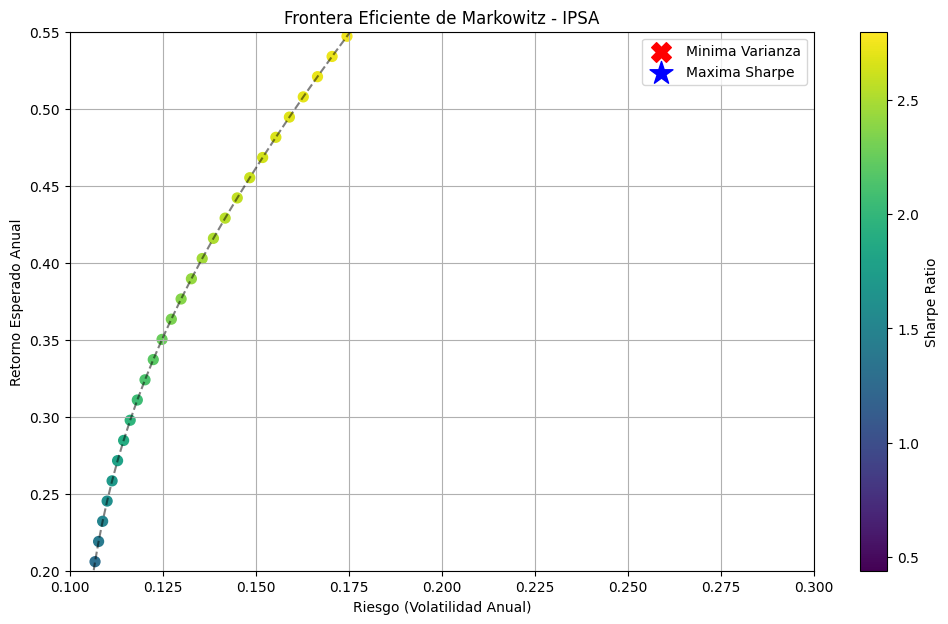

In [12]:
# 10. Graficamos frontera eficiente
plt.figure(figsize=(12, 7)) #Definimos pulgadas (tamaño)

sc = plt.scatter(frontier_risks, frontier_returns, c=frontier_sharpes, cmap='viridis', s=50) #creamos nuestro gráfico de dispersión (scatter plot)
plt.plot(frontier_risks, frontier_returns, 'k--', alpha=0.5) #Dibujamos una línea que conecta todos los puntos de la frontera eficiente
plt.colorbar(sc, label='Sharpe Ratio') #Agregamos una barra de colores al gráfico, que indica el rango de los valores del ratio de Sharpe.

# Marcamos portafolios clave
plt.scatter(vol_min, ret_min, marker='X', color='red', s=200, label='Minima Varianza')
plt.scatter(vol_sharpe, ret_sharpe, marker='*', color='blue', s=300, label='Maxima Sharpe')

plt.title('Frontera Eficiente de Markowitz - IPSA')
plt.xlabel('Riesgo (Volatilidad Anual)')
plt.ylabel('Retorno Esperado Anual')
plt.legend() #Mostramos la leyenda del gráfico, que ayuda a identificar qué representan los puntos y las líneas
plt.grid(True) #Activamos la cuadrícula en el gráfico para facilitar la visualización de los valores.
plt.xlim(0.10, 0.30)
plt.ylim(0.20, 0.55)
plt.show()


#Mostramos la frontera eficiente con color según el ratio de Sharpe.
#Señalamos los portafolios de mínima varianza y máxima Sharpe.
#Personalizamos los ejes y colores para mejor interpretación.

In [13]:
#11 Opcional (grafico dinámico)
import plotly.express as px #Librería de alto nivel para crear gráficos rápidamente
import plotly.graph_objects as go #Permite mayor personalización (como agregar puntos especiales o modificar detalles).

#Creamos DataFrame para Plotly
df_plotly = df_completo.copy()
#Crea una copia de df_completo, que contiene:
##Retorno, riesgo, Sharpe Ratio

# Gráfico interactivo
fig = px.scatter(
    df_plotly,
    x="Riesgo (Volatilidad)",
    y="Retorno Esperado",
    color="Sharpe Ratio",
    hover_data=df_plotly.columns, #Al pasar el cursor sobre un punto del gráfico, se mostrarán todos los datos disponibles en ese renglón del DataFrame.
    title="Frontera Eficiente de Markowitz - IPSA",
    color_continuous_scale="viridis"
)
#Estamos creando un gráfico de dispersión donde:
##X = Riesgo (volatilidad).
##Y = Retorno esperado.
##Color = Sharpe Ratio (escala de colores continua).
##hover_data: Al pasar el mouse por un punto, muestra todos los datos del portafolio, incluyendo pesos por acción.
##title: Título del gráfico.
##amp: Paleta de colores (de bajo a alto valor de Sharpe).


# Añadimos portafolio mínima varianza
fig.add_trace(go.Scatter(
    x=[vol_min],
    y=[ret_min],
    mode='markers+text',
    marker=dict(color='brown', size=15, symbol='x'),
    text=["Mínima Varianza"],
    textposition="top center",
    name='Mínima Varianza'
))
#Agregamos un punto azul con símbolo "X" en la ubicación del portafolio de mínima varianza.
#Se muestra con texto encima: “Mínima Varianza”.


# Añadimos portafolio máxima Sharpe
fig.add_trace(go.Scatter(
    x=[vol_sharpe],
    y=[ret_sharpe],
    mode='markers+text',
    marker=dict(color='blue', size=15, symbol='star'),
    text=["Máxima Sharpe"],
    textposition="top center",
    name='Máxima Sharpe'
))
#Agregamos un punto rojo con forma de estrella en el portafolio de máxima Sharpe.
#También muestra texto encima.



fig.update_layout(
    xaxis_title='Riesgo (Volatilidad Anual)',
    yaxis_title='Retorno Esperado Anual',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    coloraxis_colorbar=dict(title="Sharpe Ratio")
)
#Etiquetas de los ejes.
#Ubicación de la leyenda (arriba a la izquierda).
#Título del colorbar (leyenda de colores) → “Sharpe Ratio”.

fig.show()

In [14]:
fig.write_html("frontera_eficiente_interactiva.html") #descargamos grafico interactivo

In [15]:
pip install tensorflow scikit-learn

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [17]:
#12 ENTRENAMIENTO ESPECIFICO DE LA RED NEURONAL

# Preparar variables predictoras (X) y variable objetivo (y)
X = df_frontera[['Riesgo (Volatilidad)', 'Retorno Esperado', 'Beta']] #Contiene las columnas que usaremos para predecir: riesgo, retorno y beta.
y = df_frontera['Sharpe Ratio'] #Variable objetivo que queremos predecir: el Sharpe Ratio.
#Intentamos predecir que tan eficiente es un portafolio (medido por el Sharpe) en función de su riesgo, retorno y sensibilidad al mercado (beta).

# Escalar características (estandarizar la información)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en entrenamiento y prueba 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Red Neuronal Multicapa (MLP)
modelo = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # Capas más profundas
    activation='relu', #función ReLU (Rectified Linear Unit)
    solver='adam', #optimizador que ajusta los pesos, eficiente y muy usado para redes neuronales.
    max_iter=2000, #máximo número de iteraciones (épocas) durante el entrenamiento.
    random_state=42,
    early_stopping=True, #detiene el entrenamiento si la validación no mejora.
    n_iter_no_change=20, #si durante 20 iteraciones no mejora, se detiene.
    validation_fraction=0.1, #usa el 10% de los datos de entrenamiento como conjunto de validación.
    verbose=True #imprime información durante el entrenamiento
)

# Entrenamiento, aquí comienza el entrenamiento real: la red ajusta sus pesos para predecir el Sharpe Ratio a partir de riesgo, retorno y beta.
modelo.fit(X_train, y_train)

# Predicción, usamos el modelo entrenado para predecir el Sharpe Ratio de los portafolios de prueba.
y_pred = modelo.predict(X_test)

# Evaluación
mse = mean_squared_error(y_test, y_pred) #Mide qué tan lejos están las predicciones del valor real. Valor cercano a 0 → mejor.
r2 = r2_score(y_test, y_pred) #Indica qué tanto varía y es explicado por X. 1.0 → modelo perfecto, 0.0 → no explica nada o Negativo → peor que una línea horizontal (la media).

print("\n🔍 MÉTRICAS DE DESEMPEÑO DEL MODELO")
print(f"MSE: {mse:.6f}")
print(f"R²: {r2:.4f}")


Iteration 1, loss = 3.74945913
Validation score: -65.158432
Iteration 2, loss = 3.60780013
Validation score: -62.545111
Iteration 3, loss = 3.47101105
Validation score: -60.060580
Iteration 4, loss = 3.33928090
Validation score: -57.695883
Iteration 5, loss = 3.21394196
Validation score: -55.432048
Iteration 6, loss = 3.09435134
Validation score: -53.331705
Iteration 7, loss = 2.98412545
Validation score: -51.391619
Iteration 8, loss = 2.88173419
Validation score: -49.497295
Iteration 9, loss = 2.78329911
Validation score: -47.684199
Iteration 10, loss = 2.68867528
Validation score: -45.917787
Iteration 11, loss = 2.59748947
Validation score: -44.197567
Iteration 12, loss = 2.50951900
Validation score: -42.516023
Iteration 13, loss = 2.42426766
Validation score: -40.884240
Iteration 14, loss = 2.34158405
Validation score: -39.326043
Iteration 15, loss = 2.26147348
Validation score: -37.849957
Iteration 16, loss = 2.18626443
Validation score: -36.435524
Iteration 17, loss = 2.11494938
V

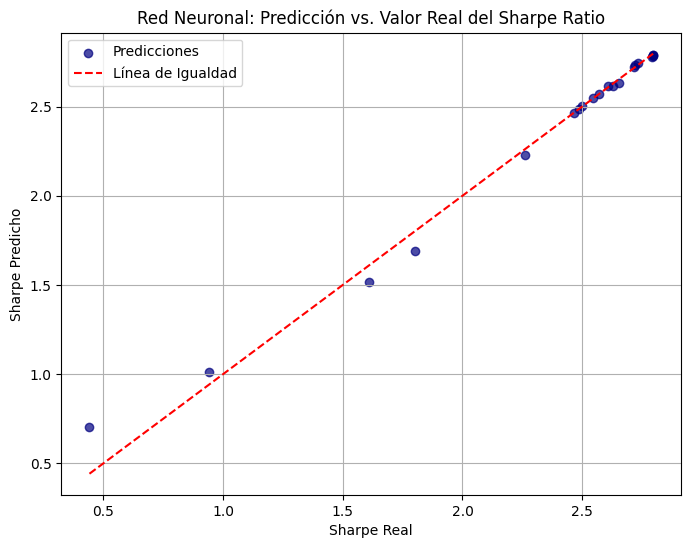

In [18]:
#13 COMPARACIÓN VISUAL

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='navy', label='Predicciones')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Línea de Igualdad')
plt.title("Red Neuronal: Predicción vs. Valor Real del Sharpe Ratio")
plt.xlabel("Sharpe Real")
plt.ylabel("Sharpe Predicho")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
#14 utilizamos modelo

import numpy as np
import pandas as pd

# Número de simulaciones (portafolios aleatorios)
n_simulaciones = 5000

# Lista de las acciones del IPSA
acciones = returns_assets.columns.tolist()

# Matriz para guardar resultados
resultados = []

# Simular 5000 portafolios con pesos aleatorios
for _ in range(n_simulaciones):
    pesos = np.random.random(len(acciones))  # Pesos aleatorios
    pesos /= np.sum(pesos)  # Normalizar: suma total = 1

    # Calcular el retorno esperado, volatilidad y beta
    retorno_esperado = np.dot(pesos, returns_assets.mean()) * 252  # Anualizado
    matriz_cov = returns_assets.cov() * 252  # Anualizada
    volatilidad = np.sqrt(np.dot(pesos.T, np.dot(matriz_cov, pesos)))

    # Beta del portafolio
    beta_portafolio = np.dot(pesos, [betas[asset] for asset in acciones])

    # Guardarmos los resultados del portafolio
    resultados.append({
        'Pesos': pesos,
        'Acciones': acciones,
        'Retorno Esperado': retorno_esperado,
        'Riesgo (Volatilidad)': volatilidad,
        'Beta': beta_portafolio
    })

# Convertirmos los resultados a un DataFrame
df_simulaciones = pd.DataFrame(resultados)

# Extraemos X (variables predictoras para la red)
X_nuevos = df_simulaciones[['Riesgo (Volatilidad)', 'Retorno Esperado', 'Beta']]

# Escalamos las variables con el mismo scaler usado en el entrenamiento (o sea estandarizamos)
X_nuevos_scaled = scaler.transform(X_nuevos)

# Predecimos el Sharpe Ratio con la red neuronal
df_simulaciones['Sharpe Estimado'] = modelo.predict(X_nuevos_scaled)

# Ordenamos los resultados por el mejor Sharpe Ratio
df_mejores = df_simulaciones.sort_values(by='Sharpe Estimado', ascending=False)

# Mostramos los 5 mejores portafolios
print("Mejores portafolios según la red neuronal:")
print(df_mejores.head())

# Creamos una nueva columna con la composición del portafolio (acciones y pesos)
df_mejores['Composición del Portafolio'] = df_mejores.apply(lambda row: dict(zip(row['Acciones'], row['Pesos'])), axis=1)

# Guardamos la composición de los mejores portafolios en un archivo Excel
df_mejores[['Composición del Portafolio', 'Retorno Esperado', 'Riesgo (Volatilidad)', 'Beta', 'Sharpe Estimado']].to_excel('mejores_portafolios_composicion.xlsx', index=False)

print("Composición de los mejores portafolios guardada en 'mejores_portafolios_composicion.xlsx'")


Mejores portafolios según la red neuronal:
                                                  Pesos  \
600   [0.05462537527185399, 0.05828384051810085, 0.0...   
4158  [0.027887813386009715, 0.03503852016139047, 0....   
1248  [0.04056333776719745, 0.04267016663665007, 0.0...   
4350  [0.06436581781329755, 0.055265152081792564, 0....   
4693  [0.056107768896971326, 0.029218644566028237, 0...   

                                               Acciones  Retorno Esperado  \
600   [AMZN, AXP, AMGN, AAPL, BA, CAT, CSCO, CVX, GS...          0.249737   
4158  [AMZN, AXP, AMGN, AAPL, BA, CAT, CSCO, CVX, GS...          0.244642   
1248  [AMZN, AXP, AMGN, AAPL, BA, CAT, CSCO, CVX, GS...          0.234292   
4350  [AMZN, AXP, AMGN, AAPL, BA, CAT, CSCO, CVX, GS...          0.230217   
4693  [AMZN, AXP, AMGN, AAPL, BA, CAT, CSCO, CVX, GS...          0.223977   

      Riesgo (Volatilidad)      Beta  Sharpe Estimado  
600               0.160429  1.148479         2.391463  
4158              0.156537 

In [20]:
#15 Hacemos un archivo de excel un poquito más entendible

#Cada columna será una acción, y cada fila un portafolio
pesos_df = pd.DataFrame(df_mejores['Pesos'].to_list(), columns=acciones)

# Concatenamos los pesos con las métricas del portafolio
df_final = pd.concat([pesos_df,
                      df_mejores[['Retorno Esperado', 'Riesgo (Volatilidad)', 'Beta', 'Sharpe Estimado']].reset_index(drop=True)],
                     axis=1)

# Guardamos el DataFrame final en un archivo Excel
df_final.to_excel('mejores_portafolios_acciones_pesos.xlsx', index=False)

print("Archivo Excel guardado con cada acción como columna: 'mejores_portafolios_acciones_pesos.xlsx'")

Archivo Excel guardado con cada acción como columna: 'mejores_portafolios_acciones_pesos.xlsx'
